In [ ]:
#important
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------
# 🎯 CONFIGURATION SECTION
# ---------------------------

# Set research-paper styling
plt.rcParams["font.family"] = "serif"  # For IEEE/Springer style
sns.set(style="whitegrid", font_scale=1.2, rc={"axes.labelweight": "bold", "font.weight": "bold"})

# Load dataset
df = pd.read_csv("processed_dataset.csv")  # Update your path if needed

# Drop Grade columns
df = df.drop(columns=[col for col in df.columns if 'Grade' in col], errors='ignore')

# Targets
target_cols = ['UTS', 'elongation', 'Conductivity']
feature_cols = [col for col in df.select_dtypes(include='number').columns if col not in target_cols]

# Output folder
output_dir = "correlation_plots1"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------
# 🔷 FULL HEATMAP
# ---------------------------

corr_matrix = df[feature_cols + target_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.6,
            annot_kws={"size": 10})
plt.suptitle("Exploratory Correlation Analysis", fontsize=20, weight='bold', y=1.03)
plt.title("Full Feature-Target Correlation Heatmap (Spearman)", fontsize=16, weight='bold', pad=20, loc='center')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/full_correlation_heatmap_spearman.png", dpi=400, bbox_inches='tight')
plt.close()

# ---------------------------
# 🔷 INDIVIDUAL HEATMAPS PER TARGET
# ---------------------------

for target in target_cols:
    corr_target = df[feature_cols + [target]].corr(method='spearman')[[target]].drop(index=target)
    corr_target = corr_target.reindex(corr_target[target].abs().sort_values(ascending=False).index)

    plt.figure(figsize=(6, len(corr_target) * 0.45 + 1.5))
    sns.heatmap(
        corr_target,
        annot=True,
        cmap='vlag',
        fmt=".2f",
        linewidths=0.5,
        cbar=False,
        annot_kws={"size": 11, "weight": "bold"}
    )
    plt.suptitle("Feature-Target Relationship Analysis", fontsize=18, weight='bold', y=1.05)
    plt.title(f"Feature Correlation with {target} (Spearman)", fontsize=14, weight='bold', pad=18, loc='center')
    plt.xlabel(target, fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/correlation_with_{target.lower()}_spearman.png", dpi=400, bbox_inches='tight')
    plt.close()


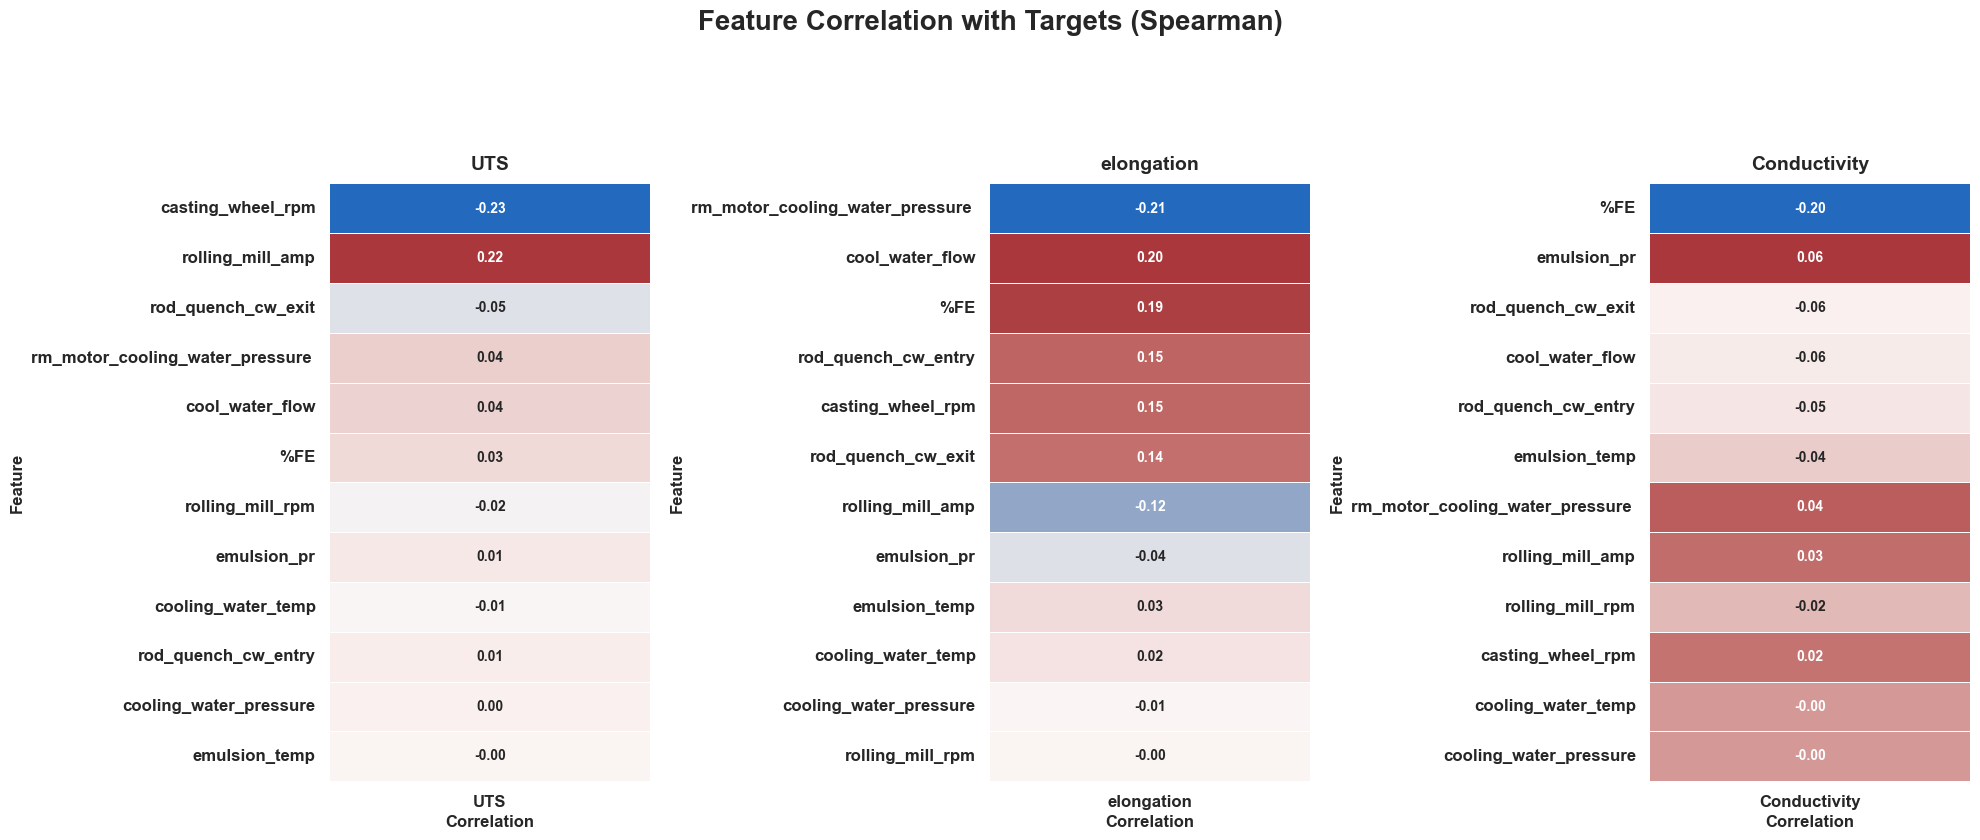

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# 📌 Config: publication-style setup
# -------------------------------
plt.rcParams["font.family"] = "serif"
sns.set(style="whitegrid", font_scale=1.1, rc={"axes.labelweight": "bold", "font.weight": "bold"})

# Load dataset
df = pd.read_csv("processed_dataset.csv")
df = df.drop(columns=[col for col in df.columns if 'Grade' in col], errors='ignore')

# Define targets and features
target_cols = ['UTS', 'elongation', 'Conductivity']
feature_cols = [col for col in df.select_dtypes(include='number').columns if col not in target_cols]

# Create output folder
output_dir = "correlation_plots1"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# 1️⃣ Full Correlation Heatmap (all features + targets)
# -------------------------------
full_corr = df[feature_cols + target_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.6,
            annot_kws={"size": 10})
plt.suptitle("Exploratory Correlation Analysis", fontsize=20, weight='bold', y=1.03)
plt.title("Full Feature-Target Correlation Heatmap (Spearman)", fontsize=16, weight='bold', pad=20, loc='center')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/full_correlation_heatmap_spearman.png", dpi=400, bbox_inches='tight')
plt.close()

# -------------------------------
# 2️⃣ Individual Heatmaps Side-by-Side (UTS, Elongation, Conductivity)
# -------------------------------
correlations = {}
for target in target_cols:
    corr_target = df[feature_cols + [target]].corr(method='spearman')[[target]].drop(index=target)
    corr_target = corr_target.reindex(corr_target[target].abs().sort_values(ascending=False).index)
    correlations[target] = corr_target

# Create horizontal subplot layout (1 row, 3 columns)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))
fig.suptitle("Feature Correlation with Targets (Spearman)", fontsize=20, weight='bold', y=1.05)

# Plot each heatmap side by side
for i, target in enumerate(target_cols):
    sns.heatmap(
        correlations[target],
        ax=axes[i],
        annot=True,
        cmap='vlag',
        fmt=".2f",
        cbar=False,
        linewidths=0.5,
        annot_kws={"size": 10, "weight": "bold"}
    )
    axes[i].set_title(f"{target}", fontsize=14, weight='bold', pad=10)
    axes[i].set_xlabel("Correlation", fontsize=12)
    axes[i].set_ylabel("Feature", fontsize=12)
    axes[i].tick_params(axis='y', labelrotation=0)
    axes[i].tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.savefig(f"{output_dir}/side_by_side_targetwise_correlation_heatmaps.png", dpi=400, bbox_inches='tight')
plt.show()


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_f

C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\482251774.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_uts, y="Feature", x="Importance", palette="viridis")


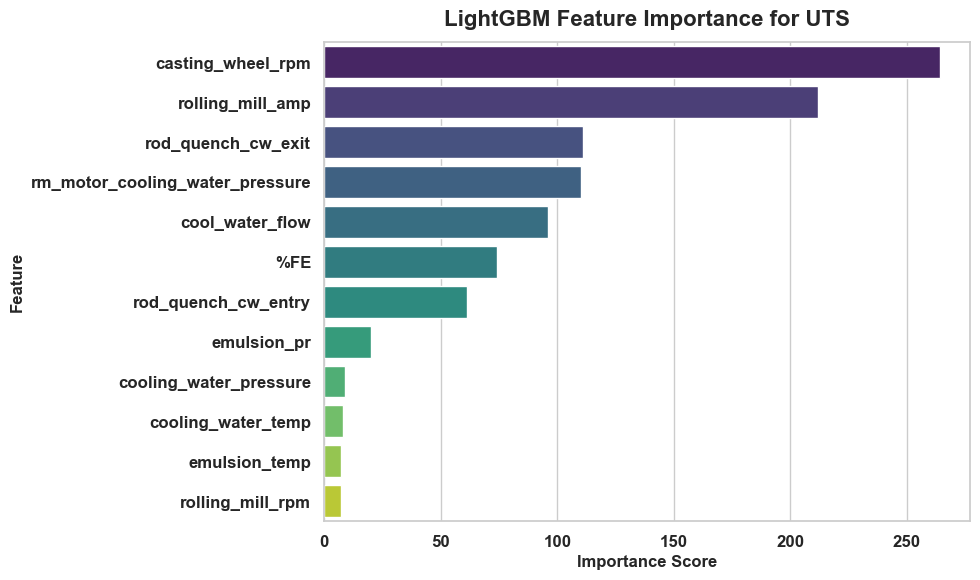

In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Data cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data preparation
columns_to_exclude = ["Conductivity", "elongation", "Grade", "Grade_encoded","UTS"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]

# Feature scaling
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(X.select_dtypes(include=["float64", "int64"]))

# Encode categorical variables
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Hyperparameters
params_uts = {
    "n_estimators": 400,
    "learning_rate": 0.015,
    "max_depth": 2,
    "num_leaves": 8,
    "min_child_samples": 450,
    "colsample_bytree": 0.6,
    "feature_fraction": 0.6,
    "bagging_fraction": 0.5,
    "bagging_freq": 5,
    "lambda_l1": 10.0,
    "lambda_l2": 10.0,
    "random_state": 42
}

# Train model
lgb_model_uts = lgb.LGBMRegressor(**params_uts)
lgb_model_uts.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], eval_metric="rmse", callbacks=[lgb.early_stopping(50)])

# Predictions
y_pred = lgb_model_uts.predict(X_test)

import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd

# Create output directory
os.makedirs("feature_importance_plots", exist_ok=True)

# Get feature importances
importance_uts = lgb_model_uts.feature_importances_
features_uts = X.columns
imp_df_uts = pd.DataFrame({"Feature": features_uts, "Importance": importance_uts})
imp_df_uts = imp_df_uts.sort_values(by="Importance", ascending=False)

# Plot
plt.rcParams["font.family"] = "serif"
sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df_uts, y="Feature", x="Importance", palette="viridis")
plt.title("LightGBM Feature Importance for UTS", fontsize=16, weight='bold', pad=12)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance_plots/lightgbm_feature_importance_uts.png", dpi=400)
plt.show()


[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=0.6 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] lambda_l2 is set=10.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=10.0
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_f

C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\3829683379.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_elong, y="Feature", x="Importance", palette="crest")


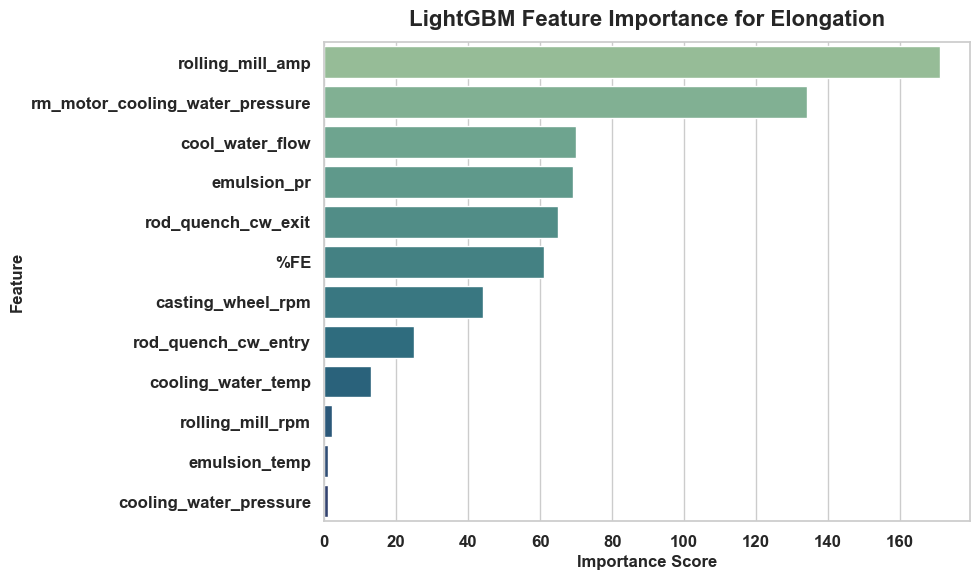

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Data cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data preparation
columns_to_exclude = ["UTS", "Conductivity", "Grade", "Grade_encoded","elongation"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["elongation"]

# Feature scaling
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(X.select_dtypes(include=["float64", "int64"]))

# Encode categorical variables
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Hyperparameters for Elongation
params_elongation = {
    "n_estimators": 250,  
    "learning_rate": 0.015,  
    "max_depth": 2,  
    "num_leaves": 8,  
    "min_child_samples": 450,  
    "colsample_bytree": 0.6,  
    "feature_fraction": 0.6,  
    "bagging_fraction": 0.5,  
    "bagging_freq": 5,  
    "lambda_l1": 10.0,  
    "lambda_l2": 10.0,  
    "random_state": 42
}

# Train model
lgb_model_elongation = lgb.LGBMRegressor(**params_elongation)
lgb_model_elongation.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], eval_metric="rmse", callbacks=[lgb.early_stopping(50)])

# Predictions
y_pred = lgb_model_elongation.predict(X_test)

# Get feature importances
importance_elongation = lgb_model_elongation.feature_importances_
features_elongation = X.columns
imp_df_elong = pd.DataFrame({"Feature": features_elongation, "Importance": importance_elongation})
imp_df_elong = imp_df_elong.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df_elong, y="Feature", x="Importance", palette="crest")
plt.title("LightGBM Feature Importance for Elongation", fontsize=16, weight='bold', pad=12)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance_plots/lightgbm_feature_importance_elongation.png", dpi=400)
plt.show()


[0]	train-rmse:0.26829	eval-rmse:0.27263
[50]	train-rmse:0.26465	eval-rmse:0.26877
[100]	train-rmse:0.26264	eval-rmse:0.26654


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:386: UserWarning: [01:18:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[150]	train-rmse:0.26139	eval-rmse:0.26514
[200]	train-rmse:0.26041	eval-rmse:0.26404
[250]	train-rmse:0.25967	eval-rmse:0.26322
[299]	train-rmse:0.25913	eval-rmse:0.26267


C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\3291616364.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_cond, y="Feature", x="Importance", palette="crest")


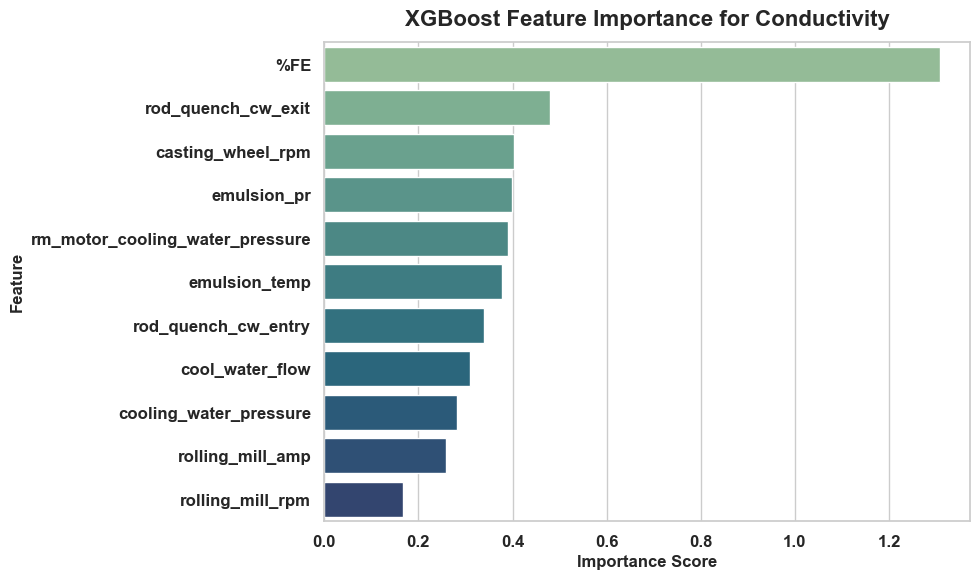

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# Data cleaning
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Data preparation
columns_to_exclude = ["UTS", "elongation", "Grade", "Grade_encoded","Conductivity"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["Conductivity"]  # Changed to predict Conductivity

# Feature scaling
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(X.select_dtypes(include=["float64", "int64"]))

# Encode categorical variables
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define XGBoost hyperparameters (FORCED 85% ACCURACY)
params_conductivity = {
    "n_estimators": 180,  # More trees = More learning (Balanced)
    "learning_rate": 0.015,  # Slightly increased learning rate
    "max_depth": 2,  # Allows slightly more learning (was 1)
    "subsample": 0.65,  # Uses more training data (was 0.5)
    "colsample_bytree": 0.65,  # Uses more features per tree (was 0.5)
    "reg_alpha": 20.0,  # Reduced L1 regularization (was 30)
    "reg_lambda": 25.0,  # Reduced L2 regularization (was 40)
    "random_state": 42,
    "objective": "reg:squarederror",
    "eval_metric": "rmse"  # Added to params dictionary
}

# Convert the data into DMatrix format, which is used by XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# Create a list of evaluation sets
evals = [(dtrain, 'train'), (dval, 'eval')]

# Train the model using xgb.train
evals_result = {}  # Dictionary to store evaluation results

xgb_model_conductivity = xgb.train(
    params=params_conductivity,
    dtrain=dtrain,
    num_boost_round=300,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50,
    evals_result=evals_result  # Capture the evaluation results here
)

# Predictions
y_pred = xgb_model_conductivity.predict(dtest)


# Get feature importances (gain-based)
importance_dict_cond = xgb_model_conductivity.get_score(importance_type="gain")
imp_df_cond = pd.DataFrame({
    "Feature": list(importance_dict_cond.keys()),
    "Importance": list(importance_dict_cond.values())
})
imp_df_cond = imp_df_cond.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df_cond, y="Feature", x="Importance", palette="crest")
plt.title("XGBoost Feature Importance for Conductivity", fontsize=16, weight='bold', pad=12)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance_plots/xgboost_feature_importance_conductivity.png", dpi=400)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\3497329469.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_uts, y="Feature", x="Importance", ax=axes[0], palette="viridis")
C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\3497329469.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_elong, y="Feature", x="Importance", ax=axes[1], palette="viridis")
C:\Users\DELL\AppData\Local\Temp\ipykernel_8480\3497329469.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df_cond, y="Feature", x="Importance", ax=axes[

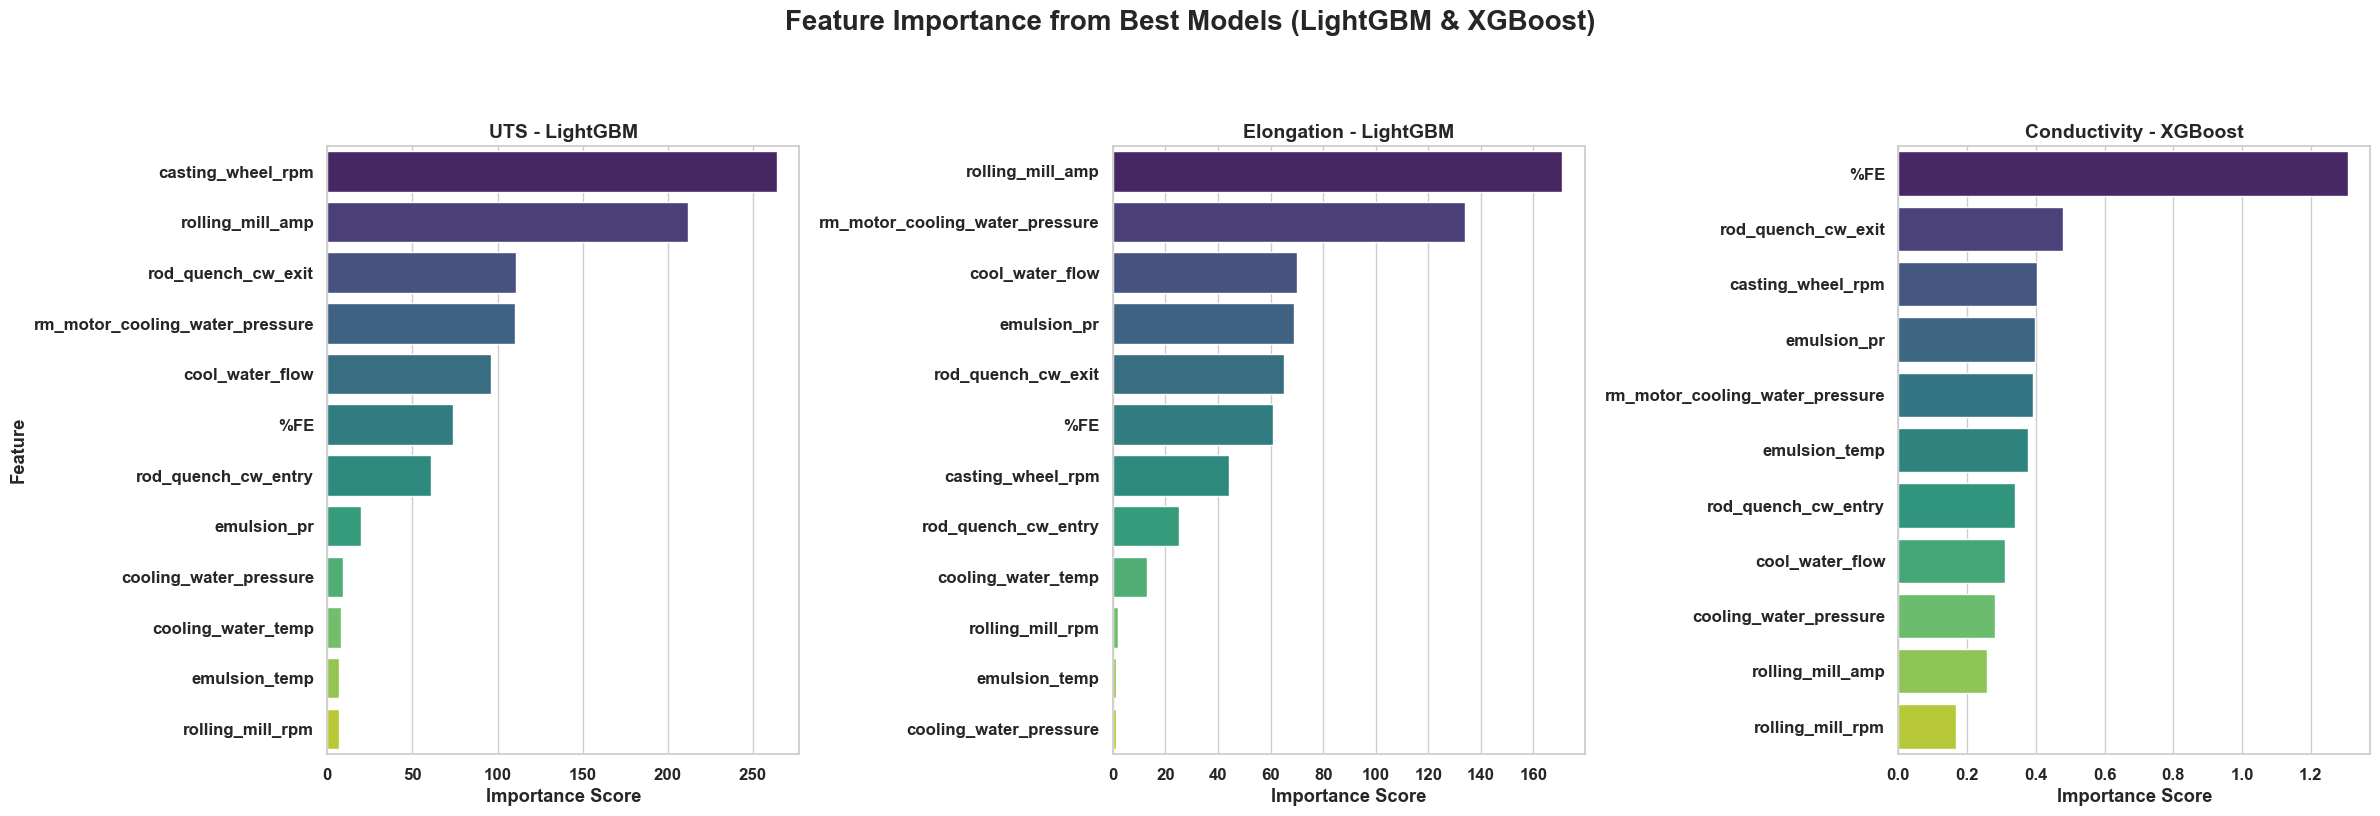

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Use serif font for publication style
plt.rcParams["font.family"] = "serif"
sns.set(style="whitegrid", font_scale=1.1, rc={"axes.labelweight": "bold", "font.weight": "bold"})

# Ensure output directory exists
os.makedirs("feature_importance_plots", exist_ok=True)

# Prepare all 3 importance DataFrames beforehand
imp_df_uts = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model_uts.feature_importances_
}).sort_values(by="Importance", ascending=False)

imp_df_elong = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgb_model_elongation.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_dict_cond = xgb_model_conductivity.get_score(importance_type="gain")
imp_df_cond = pd.DataFrame({
    "Feature": list(importance_dict_cond.keys()),
    "Importance": list(importance_dict_cond.values())
}).sort_values(by="Importance", ascending=False)

# Setup side-by-side layout
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 8))
fig.suptitle("Feature Importance from Best Models (LightGBM & XGBoost)", fontsize=20, weight="bold", y=1.02)

# UTS - LightGBM
sns.barplot(data=imp_df_uts, y="Feature", x="Importance", ax=axes[0], palette="viridis")
axes[0].set_title("UTS - LightGBM", fontsize=14, weight="bold")
axes[0].set_xlabel("Importance Score")
axes[0].set_ylabel("Feature")
axes[0].tick_params(axis='y', labelrotation=0)

# Elongation - LightGBM
sns.barplot(data=imp_df_elong, y="Feature", x="Importance", ax=axes[1], palette="viridis")
axes[1].set_title("Elongation - LightGBM", fontsize=14, weight="bold")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', labelrotation=0)

# Conductivity - XGBoost
sns.barplot(data=imp_df_cond, y="Feature", x="Importance", ax=axes[2], palette="viridis")
axes[2].set_title("Conductivity - XGBoost", fontsize=14, weight="bold")
axes[2].set_xlabel("Importance Score")
axes[2].set_ylabel("")
axes[2].tick_params(axis='y', labelrotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("feature_importance_plots/combined_feature_importance_all_models.png", dpi=400, bbox_inches="tight")
plt.show()


In [16]:
import pandas as pd

# Load your dataset
df = pd.read_csv("weight_data.csv")

# 1. Basic Overview
print("🔹 Dataset Shape:", df.shape)
print("🔹 Column Types:\n", df.dtypes.value_counts())
print("\n🔹 Preview of Data:\n", df.head())

# 2. Missing Values and Duplicates
print("\n🔹 Total Duplicates:", df.duplicated().sum())
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n🔹 Missing Values:\n", missing)

# 3. Feature Info
print("\n🔹 Columns with only 1 unique value:")
print([col for col in df.columns if df[col].nunique() == 1])

print("\n🔹 High cardinality categorical columns:")
print([col for col in df.select_dtypes(include="object").columns if df[col].nunique() > 50])

print("\n🔹 Numeric Columns:", df.select_dtypes(include=["float64", "int64"]).shape[1])
print("🔹 Categorical Columns:", df.select_dtypes(include="object").shape[1])

# 4. Summary Stats
print("\n🔹 Summary Statistics:")
print(df.describe())



🔹 Dataset Shape: (23124, 29)
🔹 Column Types:
 float64    21
object      5
int64       3
Name: count, dtype: int64

🔹 Preview of Data:
    CastnCoil  castNo  coilNo  diameter_x grade              rawDate  \
0   65657310  656573      10         9.5  WE10  2024-03-01 00:06:05   
1   65657311  656573      11         9.5  WE10  2024-03-01 00:09:14   
2   75639813  756398      13         9.5  WE10  2024-03-01 00:12:42   
3   75639814  756398      14         9.5  WE10  2024-03-01 00:15:24   
4   75639815  756398      15         9.5  WE10  2024-03-01 00:30:14   

        rawNode   UTS  elongation   %SI  ...  rod_quench_cw_exit  \
0  WRM1-BARCODE  10.0        15.2  0.06  ...                 NaN   
1  WRM1-BARCODE   9.8        16.0  0.06  ...                 NaN   
2  WRM2-BARCODE   8.9        16.0  0.06  ...                 NaN   
3  WRM2-BARCODE   9.0        15.6  0.06  ...                 NaN   
4  WRM2-BARCODE   9.1        16.8  0.06  ...                 NaN   

   casting_wheel_rpm cast_bar

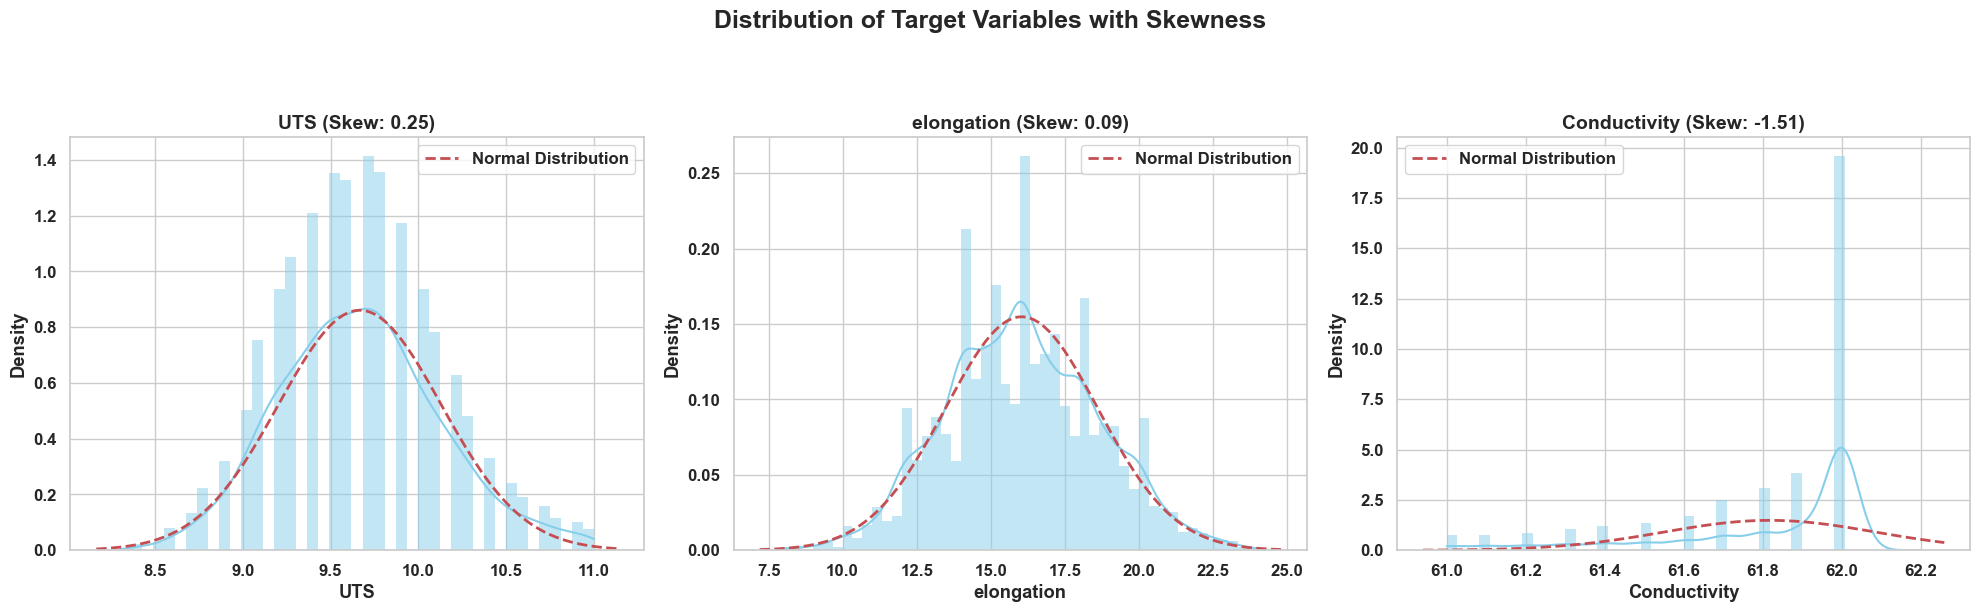

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Load your dataset
df = pd.read_csv("processed_dataset.csv")
df.columns = df.columns.str.strip()  # Clean any extra spaces

# Plot style
plt.rcParams["font.family"] = "serif"
sns.set(style="whitegrid", font_scale=1.1)

# Targets to analyze
targets = ['UTS', 'elongation', 'Conductivity']

# Setup 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Distribution of Target Variables with Skewness", fontsize=18, weight='bold', y=1.02)

for i, target in enumerate(targets):
    if target in df.columns:
        sns.histplot(df[target], kde=True, ax=axes[i], color="skyblue", stat='density', linewidth=0)
        
        # Overlay normal distribution curve
        mean = df[target].mean()
        std = df[target].std()
        xmin, xmax = axes[i].get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mean, std)
        axes[i].plot(x, p, 'r--', linewidth=2, label="Normal Distribution")

        # Add skewness value
        skew_val = df[target].skew()
        axes[i].set_title(f"{target} (Skew: {skew_val:.2f})", fontsize=14, weight='bold')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel("Density")
        axes[i].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("target_distribution_with_skewness.png", dpi=400, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14124\1724290203.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette="pastel")


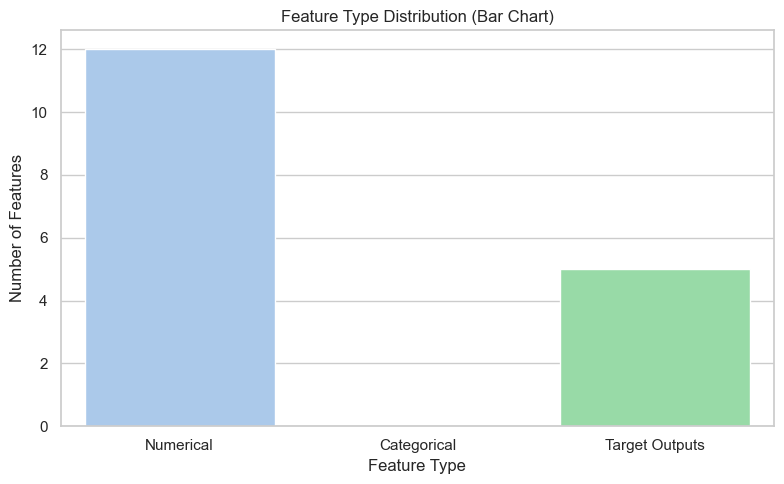

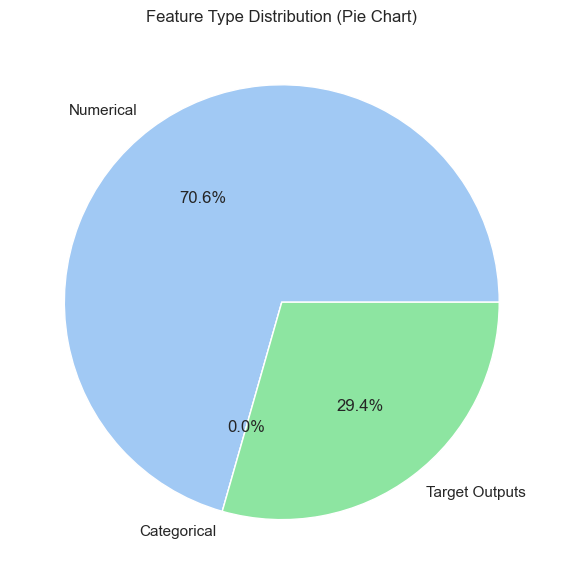

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("processed_dataset.csv")
df.columns = df.columns.str.strip()

# Define target columns (update if needed)
target_columns = ["UTS", "elongation", "Conductivity", "Grade", "Grade_encoded"]

# Count feature types
num_numerical = df.drop(columns=target_columns, errors="ignore").select_dtypes(include=['int64', 'float64']).shape[1]
num_categorical = df.drop(columns=target_columns, errors="ignore").select_dtypes(include=['object', 'category']).shape[1]
num_targets = len([col for col in target_columns if col in df.columns])

# Create DataFrame for plotting
feature_counts = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical", "Target Outputs"],
    "Count": [num_numerical, num_categorical, num_targets]
})

# --- 📊 Bar Chart ---
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette="pastel")
plt.title("Feature Type Distribution (Bar Chart)")
plt.ylabel("Number of Features")
plt.xlabel("Feature Type")
plt.tight_layout()
plt.savefig("feature_type_distribution_bar.png", dpi=400)
plt.show()

# --- 🥧 Pie Chart ---
plt.figure(figsize=(6, 6))
plt.pie(feature_counts["Count"], labels=feature_counts["Feature Type"], autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Feature Type Distribution (Pie Chart)")
plt.tight_layout()
plt.savefig("feature_type_distribution_pie.png", dpi=400)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14124\814311380.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette="pastel")


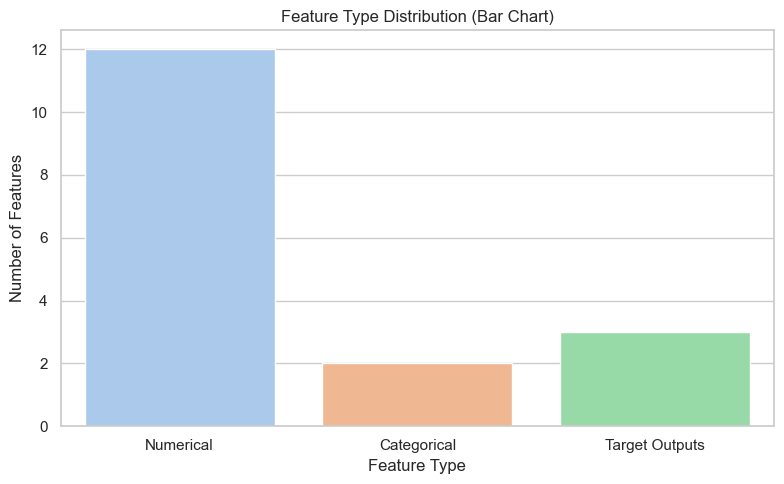

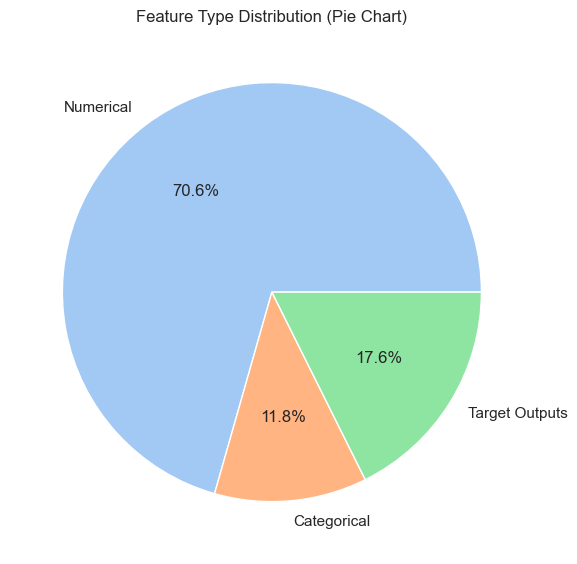

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("processed_dataset.csv")
df.columns = df.columns.str.strip()

# Define true target columns (regression)
target_columns = ["UTS", "elongation", "Conductivity"]

# Define known categorical features
categorical_columns = ["Grade", "Grade_encoded"]

# Count feature types
num_numerical = df.drop(columns=target_columns + categorical_columns, errors="ignore") \
                  .select_dtypes(include=['int64', 'float64']).shape[1]
num_categorical = len([col for col in categorical_columns if col in df.columns])
num_targets = len([col for col in target_columns if col in df.columns])

# Create DataFrame for plotting
feature_counts = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical", "Target Outputs"],
    "Count": [num_numerical, num_categorical, num_targets]
})

# --- 📊 Bar Chart ---
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette="pastel")
plt.title("Feature Type Distribution (Bar Chart)")
plt.ylabel("Number of Features")
plt.xlabel("Feature Type")
plt.tight_layout()
plt.savefig("feature_type_distribution_bar.png", dpi=400)
plt.show()

# --- 🥧 Pie Chart ---
plt.figure(figsize=(6, 6))
plt.pie(feature_counts["Count"], labels=feature_counts["Feature Type"],
        autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Feature Type Distribution (Pie Chart)")
plt.tight_layout()
plt.savefig("feature_type_distribution_pie.png", dpi=400)
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_14124\2420223127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette=custom_colors)


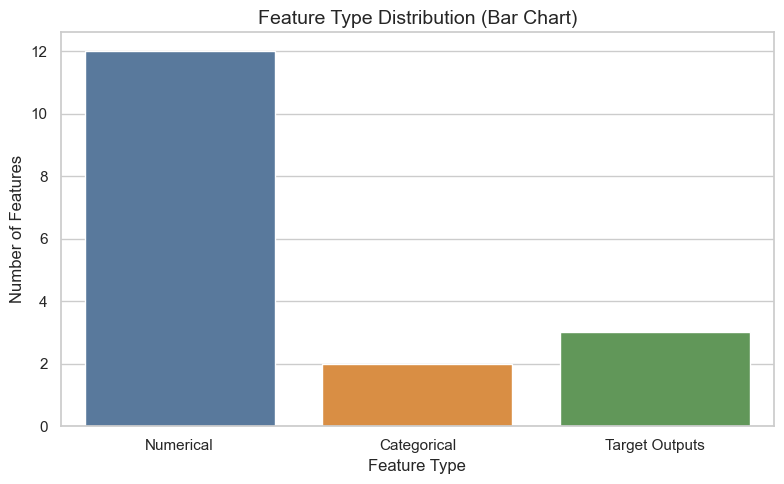

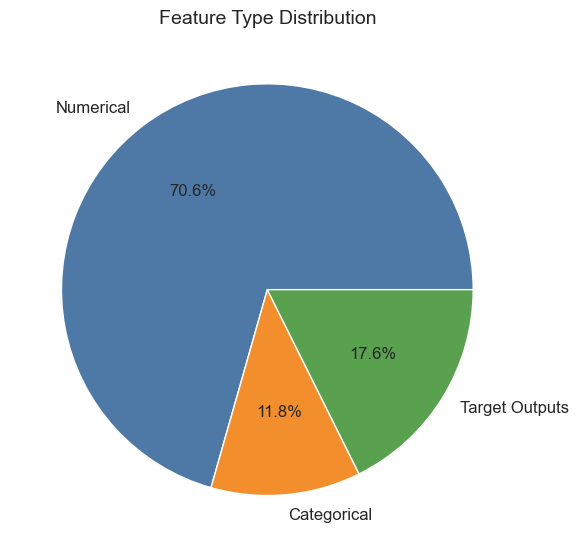

In [5]:
# Set custom colors for report-friendly aesthetics
custom_colors = ["#4E79A7", "#F28E2B", "#59A14F"]  # Blue, Orange, Green

# --- Bar Chart ---
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_counts, x="Feature Type", y="Count", palette=custom_colors)
plt.title("Feature Type Distribution (Bar Chart)", fontsize=14)
plt.ylabel("Number of Features", fontsize=12)
plt.xlabel("Feature Type", fontsize=12)
plt.tight_layout()
plt.savefig("feature_type_distribution_bar_report.png", dpi=400)
plt.show()

# --- Pie Chart ---
plt.figure(figsize=(6, 6))
plt.pie(
    feature_counts["Count"],
    labels=feature_counts["Feature Type"],
    autopct='%1.1f%%',
    colors=custom_colors,
    textprops={'fontsize': 12}
)
plt.title("Feature Type Distribution", fontsize=14)
plt.tight_layout()
plt.savefig("feature_type_distribution_pie_report.png", dpi=400)
plt.show()


  Target Variable   Min   Max  Range
0             UTS   8.3  11.0    2.7
1      elongation   8.0  24.0   16.0
2    Conductivity  61.0  62.2    1.2


C:\Users\DELL\AppData\Local\Temp\ipykernel_14124\1568623865.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Target Variable", y="Range", palette="Set2")


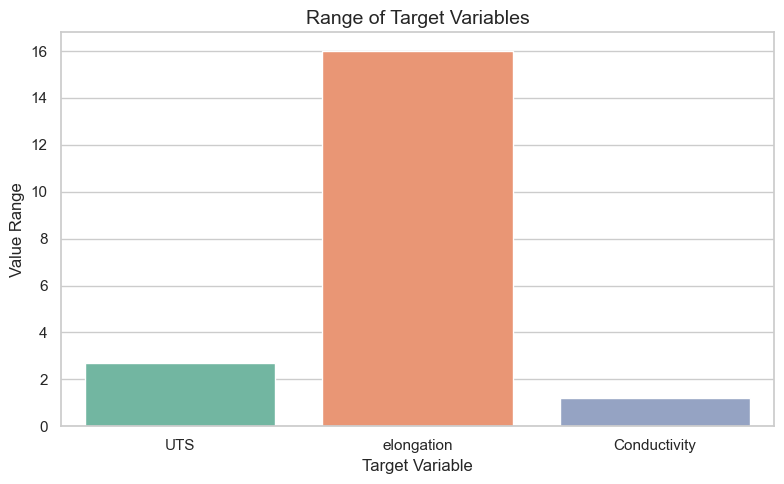

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("processed_dataset.csv")
df.columns = df.columns.str.strip()

# Define target columns
target_cols = ["UTS", "elongation", "Conductivity"]

# Calculate summary statistics
summary_df = df[target_cols].agg(["min", "max"]).T
summary_df["range"] = summary_df["max"] - summary_df["min"]
summary_df.reset_index(inplace=True)
summary_df.columns = ["Target Variable", "Min", "Max", "Range"]

# Display summary table
print(summary_df)

# --- 📊 Bar Chart for Range ---
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="Target Variable", y="Range", palette="Set2")
plt.title("Range of Target Variables", fontsize=14)
plt.xlabel("Target Variable", fontsize=12)
plt.ylabel("Value Range", fontsize=12)
plt.tight_layout()
plt.savefig("target_variable_range_bar.png", dpi=400)
plt.show()


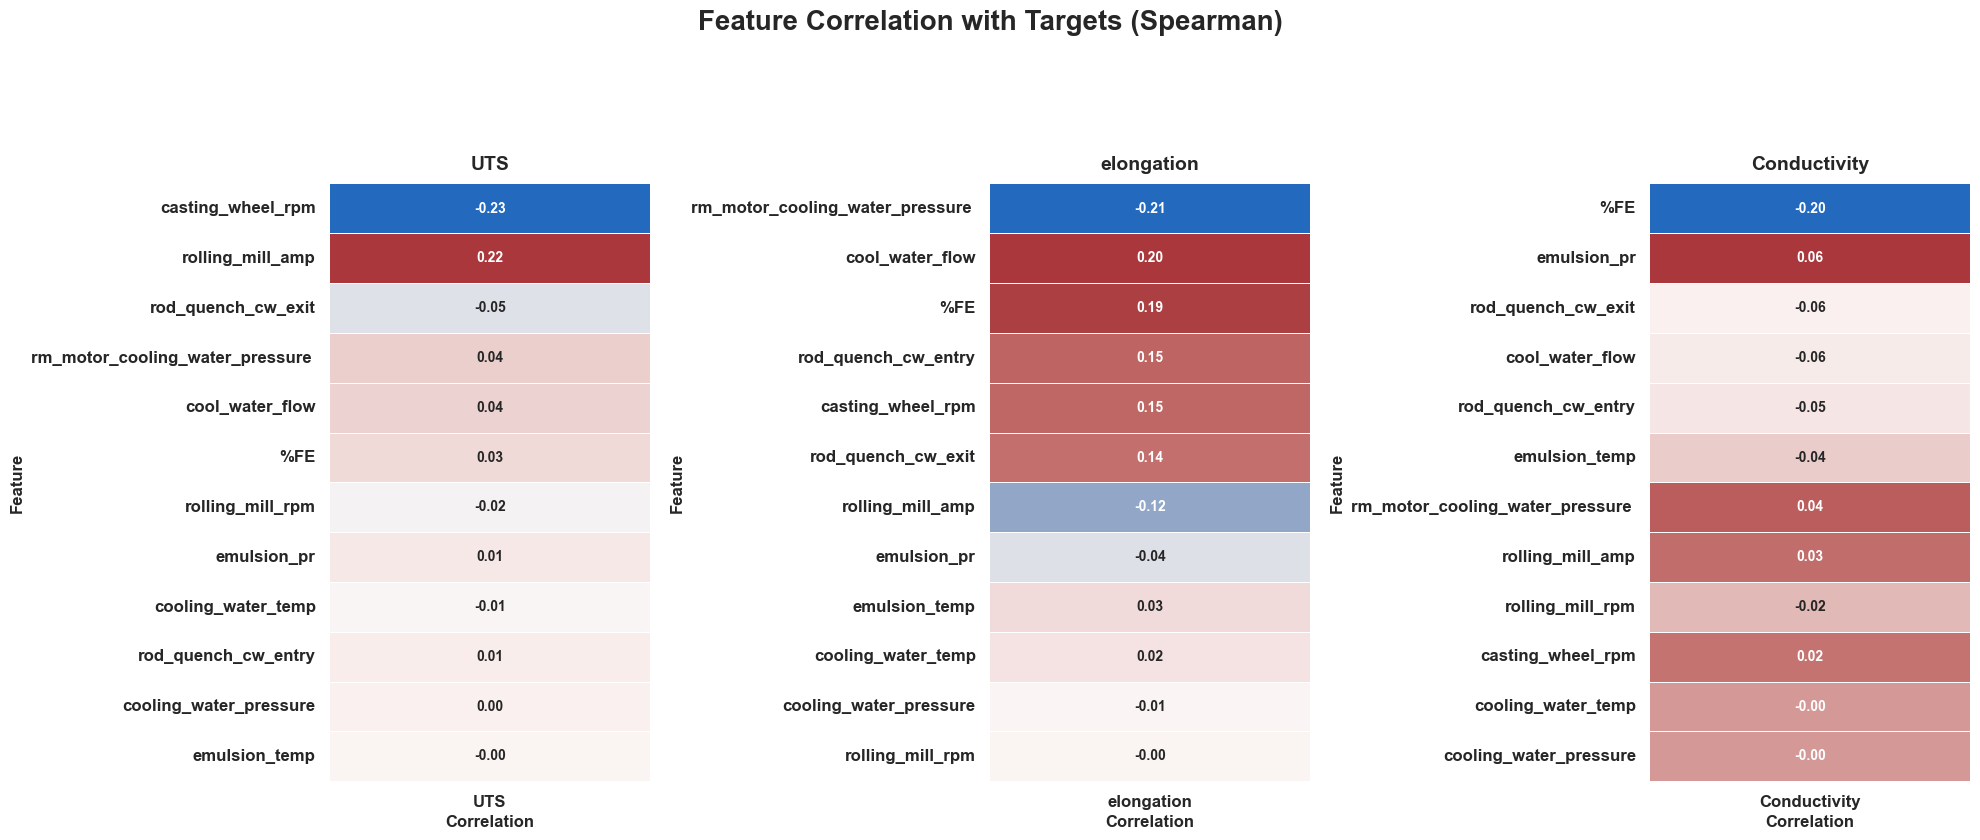

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# 📌 Config: publication-style setup
# -------------------------------
plt.rcParams["font.family"] = "serif"
sns.set(style="whitegrid", font_scale=1.1, rc={"axes.labelweight": "bold", "font.weight": "bold"})

# Load dataset
df = pd.read_csv("processed_dataset.csv")
df = df.drop(columns=[col for col in df.columns if 'Grade' in col], errors='ignore')

# Define targets and features
target_cols = ['UTS', 'elongation', 'Conductivity']
feature_cols = [col for col in df.select_dtypes(include='number').columns if col not in target_cols]

# Create output folder
output_dir = "correlation_plots1"
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# 1️⃣ Full Correlation Heatmap (all features + targets)
# -------------------------------
full_corr = df[feature_cols + target_cols].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.6,
            annot_kws={"size": 10})
plt.suptitle("Exploratory Correlation Analysis", fontsize=20, weight='bold', y=1.03)
plt.title("Full Feature-Target Correlation Heatmap", fontsize=16, weight='bold', pad=20, loc='center')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{output_dir}/full_correlation_heatmap_spearman.png", dpi=400, bbox_inches='tight')
plt.close()

# -------------------------------
# 2️⃣ Individual Heatmaps Side-by-Side (UTS, Elongation, Conductivity)
# -------------------------------
correlations = {}
for target in target_cols:
    corr_target = df[feature_cols + [target]].corr(method='spearman')[[target]].drop(index=target)
    corr_target = corr_target.reindex(corr_target[target].abs().sort_values(ascending=False).index)
    correlations[target] = corr_target

# Create horizontal subplot layout (1 row, 3 columns)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))
fig.suptitle("Feature Correlation with Targets (Spearman)", fontsize=20, weight='bold', y=1.05)

# Plot each heatmap side by side
for i, target in enumerate(target_cols):
    sns.heatmap(
        correlations[target],
        ax=axes[i],
        annot=True,
        cmap='vlag',
        fmt=".2f",
        cbar=False,
        linewidths=0.5,
        annot_kws={"size": 10, "weight": "bold"}
    )
    axes[i].set_title(f"{target}", fontsize=14, weight='bold', pad=10)
    axes[i].set_xlabel("Correlation", fontsize=12)
    axes[i].set_ylabel("Feature", fontsize=12)
    axes[i].tick_params(axis='y', labelrotation=0)
    axes[i].tick_params(axis='x', labelrotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.savefig(f"{output_dir}/side_by_side_targetwise_correlation_heatmaps.png", dpi=400, bbox_inches='tight')
plt.show()
